### Problem Statement

    Predict daily chai sales for a roadside chai-wala based on weather conditions. This is a regression problem because we're predicting a continuous number (cups of chai sold).


    Dataset Description
    •	Features (Inputs): Temperature (°C), Humidity (%), Is_Rainy (0/1), Is_Weekend (0/1)
    •	Target (Output): Cups of chai sold (continuous number)
    •	Samples: 500 synthetic daily records

In [ ]:
# ============================================
# EXAMPLE 1: Chai Sales Prediction (Regression)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import layers # type: ignore

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Generate synthetic chai sales data
n_samples = 500

/opt/homebrew/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Feature generation with realistic Indian weather patterns
temperature = np.random.uniform(10, 45, n_samples)    # 10°C to 45°C
humidity = np.random.uniform(30, 95, n_samples)       # 30% to 95%
is_rainy = np.random.binomial(1, 0.3, n_samples)      # 30% rainy days
is_weekend = np.random.binomial(1, 0.286, n_samples)  # ~2/7 days are weekend

In [3]:
# Create realistic target: Chai sales logic
# Lower temp = more chai, Rain = more chai, Weekend = more chai
base_sales = 100
temp_effect = -2 * (temperature - 25)  # Negative: higher temp = fewer sales
humidity_effect = 0.3 * humidity       # Slight positive effect
rain_effect = 40 * is_rainy           # Rain boosts sales by ~40 cups
weekend_effect = 25 * is_weekend      # Weekends boost by ~25 cups

In [4]:
noise = np.random.normal(0, 10, n_samples)  # Random variation

chai_sales = base_sales + temp_effect + humidity_effect + rain_effect + weekend_effect + noise
chai_sales = np.maximum(chai_sales, 20)  # Minimum 20 cups/day

print(f'Generated {n_samples} samples')
print(f'Chai sales range: {chai_sales.min():.0f} to {chai_sales.max():.0f} cups')

Generated 500 samples
Chai sales range: 57 to 226 cups


In [ ]:
# Create DataFrame for better visualization
df = pd.DataFrame({
    'Temperature': temperature,
    'Humidity': humidity,
    'Is_Rainy': is_rainy,
    'Is_Weekend': is_weekend,
    'Chai_Sales': chai_sales
})

print('\nDataset Sample:')
print(df.head(10))
print('\nDataset Statistics:')
print(df.describe())


Dataset Sample:
   Temperature   Humidity  Is_Rainy  Is_Weekend  Chai_Sales
0    23.108904  75.380511         0           0  117.616519
1    43.275001  64.846264         0           0   74.635074
2    35.619788  50.119295         1           0  131.531424
3    30.953047  82.896676         1           0  156.636564
4    15.460652  74.507526         1           0  190.566799
5    15.459808  40.570101         0           0  123.219624
6    12.032926  89.210267         0           0  167.624113
7    40.316165  83.464921         1           0  131.695910
8    31.039025  91.736994         0           0  115.229375
9    34.782540  77.171768         0           1  121.114333

Dataset Statistics:
       Temperature    Humidity    Is_Rainy  Is_Weekend  Chai_Sales
count   500.000000  500.000000  500.000000  500.000000  500.000000
mean     27.449660   61.326841    0.322000    0.286000  133.705826
std      10.454094   18.557075    0.467711    0.452342   31.684520
min      10.177155   30.301081    

In [6]:
# Prepare features (X) and target (y)
X = df[['Temperature', 'Humidity', 'Is_Rainy', 'Is_Weekend']].values
y = df['Chai_Sales'].values

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'\nTraining samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')



Training samples: 400
Testing samples: 100


In [7]:
# IMPORTANT: Scale features for better neural network performance
# Neural networks work best when inputs are in similar ranges
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data
X_test_scaled = scaler.transform(X_test)        # Transform test data

print('\nScaling complete! Features now have mean≈0 and std≈1')



Scaling complete! Features now have mean≈0 and std≈1


In [8]:
# Build the ANN model for regression
# Architecture: Input(4) -> Hidden(64, ReLU) -> Hidden(32, ReLU) -> Output(1, Linear)

model = keras.Sequential([
    # Input layer is implicit - Keras infers from input_shape
    
    # First Hidden Layer: 64 neurons with ReLU activation
    # input_shape=(4,) tells Keras we have 4 input features
    layers.Dense(64, activation='relu', input_shape=(4,), name='hidden_1'),
    
    # Second Hidden Layer: 32 neurons with ReLU activation
    # Gradually reducing neurons is a common pattern
    layers.Dense(32, activation='relu', name='hidden_2'),
    
    # Output Layer: 1 neuron, NO activation (linear)
    # For regression, we want the raw predicted value
    layers.Dense(1, name='output')
])


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Display model architecture
print('\n' + '='*50)
print('CHAI SALES PREDICTION MODEL ARCHITECTURE')
print('='*50)
model.summary()

# Understanding the parameters:
# Hidden 1: (4 inputs × 64 neurons) + 64 biases = 320 parameters
# Hidden 2: (64 inputs × 32 neurons) + 32 biases = 2,080 parameters
# Output: (32 inputs × 1 neuron) + 1 bias = 33 parameters
# Total: 320 + 2,080 + 33 = 2,433 trainable parameters



CHAI SALES PREDICTION MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
# - optimizer='adam': Adaptive learning rate optimizer (best default choice)
# - loss='mse': Mean Squared Error for regression
# - metrics=['mae']: Track Mean Absolute Error for interpretability

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print('\nModel compiled! Ready for training...')
print('Loss function: Mean Squared Error (MSE)')
print('Optimizer: Adam')



Model compiled! Ready for training...
Loss function: Mean Squared Error (MSE)
Optimizer: Adam


In [13]:
# Train the model
# - epochs=100: Pass through entire dataset 100 times
# - batch_size=32: Update weights after every 32 samples
# - validation_split=0.2: Use 20% of training data for validation
# - verbose=1: Show training progress

print('\n' + '='*50)
print('TRAINING STARTED')
print('='*50)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print('\nTraining complete!')



TRAINING STARTED
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 87.3808 - mae: 7.4531 - val_loss: 104.9372 - val_mae: 7.9040
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 87.3518 - mae: 7.4518 - val_loss: 104.8716 - val_mae: 7.9020
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 87.3243 - mae: 7.4504 - val_loss: 104.8002 - val_mae: 7.8998
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87.2949 - mae: 7.4491 - val_loss: 104.7164 - val_mae: 7.8969
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87.2634 - mae: 7.4476 - val_loss: 104.6242 - val_mae: 7.8941
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87.2377 - mae: 7.4462 - val_loss: 104.5553 - val_mae: 7.8917
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87.2084 - mae: 7.4448 - val_loss: 104.4939 - val_mae: 7.8900
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87.1812 - mae: 7.4434 - val_loss: 104.4127 - val_mae: 7.8879
Epoch 9/100
10/10 ━━━

In [14]:
# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print('\n' + '='*50)
print('MODEL EVALUATION RESULTS')
print('='*50)
print(f'Test MSE Loss: {test_loss:.2f}')
print(f'Test MAE: {test_mae:.2f} cups')



MODEL EVALUATION RESULTS
Test MSE Loss: 119.64
Test MAE: 7.94 cups



Interpretation: On average, predictions are off by ~8 cups
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


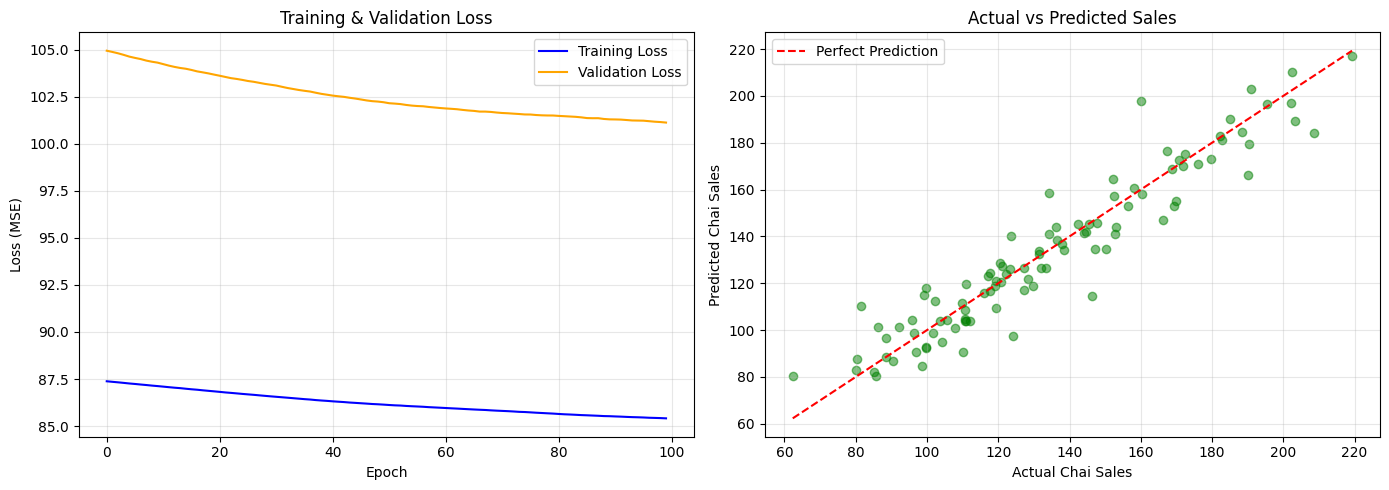


Visualization saved as chai_sales_results.png


In [15]:
print(f'\nInterpretation: On average, predictions are off by ~{test_mae:.0f} cups')

# Make predictions
y_pred = model.predict(X_test_scaled).flatten()

# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss over epochs
axes[0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted
axes[1].scatter(y_test, y_pred, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', label='Perfect Prediction')
axes[1].set_xlabel('Actual Chai Sales')
axes[1].set_ylabel('Predicted Chai Sales')
axes[1].set_title('Actual vs Predicted Sales')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chai_sales_results.png', dpi=150)
plt.show()

print('\nVisualization saved as chai_sales_results.png')


In [16]:
# Test with realistic scenarios
print('\n' + '='*50)
print('REAL-WORLD PREDICTION SCENARIOS')
print('='*50)

scenarios = [
    {'name': 'Cold Rainy Monday', 'temp': 15, 'humidity': 90, 'rain': 1, 'weekend': 0},
    {'name': 'Hot Sunny Weekday', 'temp': 42, 'humidity': 40, 'rain': 0, 'weekend': 0},
    {'name': 'Pleasant Weekend', 'temp': 25, 'humidity': 60, 'rain': 0, 'weekend': 1},
    {'name': 'Monsoon Weekend', 'temp': 28, 'humidity': 95, 'rain': 1, 'weekend': 1},
]

for scenario in scenarios:
    # Prepare input
    X_new = np.array([[scenario['temp'], scenario['humidity'], 
                       scenario['rain'], scenario['weekend']]])
    X_new_scaled = scaler.transform(X_new)
    
    # Predict
    prediction = model.predict(X_new_scaled, verbose=0)[0][0]
    
    print(f"\n{scenario['name']}:")
    print(f"  Temperature: {scenario['temp']}°C, Humidity: {scenario['humidity']}%")
    print(f"  Rainy: {'Yes' if scenario['rain'] else 'No'}, Weekend: {'Yes' if scenario['weekend'] else 'No'}")
    print(f"  → Predicted Chai Sales: {prediction:.0f} cups")



REAL-WORLD PREDICTION SCENARIOS

Cold Rainy Monday:
  Temperature: 15°C, Humidity: 90%
  Rainy: Yes, Weekend: No
  → Predicted Chai Sales: 196 cups

Hot Sunny Weekday:
  Temperature: 42°C, Humidity: 40%
  Rainy: No, Weekend: No
  → Predicted Chai Sales: 81 cups

Pleasant Weekend:
  Temperature: 25°C, Humidity: 60%
  Rainy: No, Weekend: Yes
  → Predicted Chai Sales: 138 cups

Monsoon Weekend:
  Temperature: 28°C, Humidity: 95%
  Rainy: Yes, Weekend: Yes
  → Predicted Chai Sales: 186 cups
